# Tutorial 03 - Empirical Covariance Estimation & Model Fitting

**Package:** stamps_v3  
**MATLAB equivalent:** `STATLIBtutorial.m` §4-end  
**Dataset:** Falmagne soil dataset

---

## Learning objectives

1. Compute **empirical spatial covariance** with `stcov`.
2. Fit a nested covariance model by **Weighted Least Squares (WLS)** with `covmodelfit`.
3. Fit a **Linear Model of Coregionalisation (LMC)** for three variables (sand, silt, clay) using `coregfit`.
4. Apply **Normal Score Transformation (NST)** with `other2gauss` and repeat the covariance workflow on the transformed data.

### Key difference from MATLAB

> MATLAB's `vario()` computes the **variogram** $\gamma(h) = \frac{1}{2}\text{E}[Z(\mathbf{s}+\mathbf{h})-Z(\mathbf{s})]^2$.  
> stamps_v3's `stcov()` computes the **covariance** $C(h) = \text{Cov}[Z(\mathbf{s}), Z(\mathbf{s}+\mathbf{h})]$.  
> They are related by $C(h) = C(0) - \gamma(h)$, but stamps uses covariances throughout.


In [1]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from stamps.stats.dependence.covariance.stcov import stcov
from stamps.stats.dependence.covariance.stcovfit import covmodelfit, coregfit
from stamps.bme.bme_transform import other2gauss
from stamps.graph.modelplot import modelplot
from stamps.graph.dataplot import histplot

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
DATA_DIR = os.path.join(os.getcwd(), 'data')

with open(os.path.join(DATA_DIR, 'tutorial01_data.pkl'), 'rb') as f:
    d = pickle.load(f)
ch = d['ch']; sand = d['sand']; silt = d['silt']; clay = d['clay']
print('Loaded:', ch.shape, sand.shape)


Loaded: (118, 2) (118,)


## 1. Empirical spatial covariance with `stcov`

`stcov` computes the empirical covariance for each spatial lag class defined by `lagS` (lag centres) and `lagS_range` (half-widths).

**Pure-spatial (1-D output):** pass `grid_t=None` and a plain 1-D data array — outputs are 1-D arrays.

```python
cov_v, cov_n, lags, _ = stcov(grid_s, None, grid_v_1d, lagS, lagS_range)
```

**Space-time (2-D output):** provide `grid_t`, `lagT`, and a 2-D `(ns, nt)` data array.

```python
lagCOVv, lagCOVn, lagSS, lagTT = stcov(
    grid_s, grid_t, grid_v,
    lagS, lagS_range,
    lagT, lagT_range
)
```

**Return values:**
- `lagCOVv` — empirical covariance values
- `lagCOVn` — number of pairs per lag class
- `lagSS`, `lagTT` — spatial and temporal lag centres


In [2]:
# Spatial lag settings (in metres)
lagS       = np.arange(0, 13_500, 500.0)   # lag centres 0..13000 m
lagS_range = np.full(len(lagS), 500.0)      # half-width 500 m

# Pure-spatial stcov: pass grid_t=None and a 1-D data array directly.
# Outputs are already 1-D arrays (no .ravel() needed).
cov_h, n_h, lag_h, _ = stcov(ch, None, sand, lagS, lagS_range)

# Remove empty bins
valid = (n_h > 0) & ~np.isnan(cov_h)
lag_h, cov_h, n_h = lag_h[valid], cov_h[valid], n_h[valid]

print(f'Lag range  : {lag_h.min():.0f} - {lag_h.max():.0f} m')
print(f'C(0)       : {cov_h[0]:.4f}')
print(f'Lag bins used: {valid.sum()}')


Lag range  : 0 - 13000 m
C(0)       : 70.1319
Lag bins used: 27


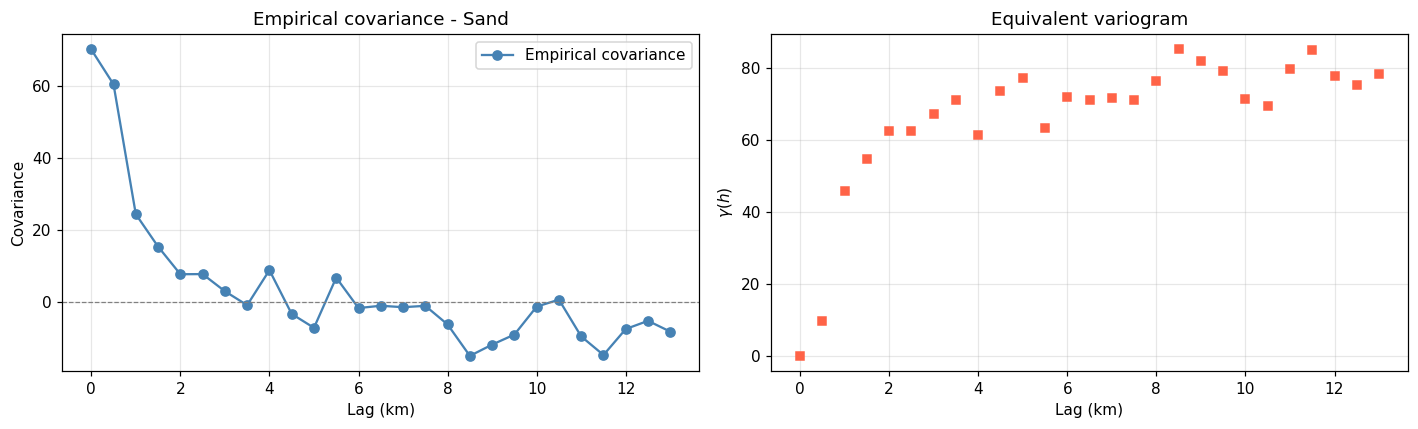

In [3]:
axs = modelplot(cov_h, lag_h, show_variogram=True, lag_scale=1000, lag_unit='km')
axs[0].set_title('Empirical covariance - Sand')
plt.tight_layout(); plt.show()


## 2. Fitting a nested covariance model by WLS

`covmodelfit` minimises the weighted sum of squared residuals between the empirical covariance values and the model prediction:

$$\text{WSS} = \sum_k n_k \left[\hat{C}(h_k) - C_{\text{model}}(h_k)\right]^2$$

where $n_k$ is the number of pairs used to estimate $\hat{C}(h_k)$.


In [4]:
# Nested model: nugget + spherical
# covparam0 = initial guesses: [sill0], [sill1, range1]
covmodel  = ['nuggetC', 'sphericalC']
covparam0 = [(20.0,), (80.0, 5_000.0)]

# covmodelfit expects:
#   covmodelfit(lag_cov_s, lag_cov_t, lag_cov_v, lag_cov_n, covmodel, covparam0)
lag_cov_s = lag_h.reshape(-1, 1)    # (n_valid, 1) spatial lags
lag_cov_t = np.array([[0.0]])        # (1, 1) dummy time lag
lag_cov_v = cov_h.reshape(-1, 1)    # (n_valid, 1) empirical covariances
lag_cov_n = n_h.reshape(-1, 1)      # (n_valid, 1) pair counts

fitted_covparam, _opt6 = covmodelfit(lag_cov_s, lag_cov_t, lag_cov_v, lag_cov_n,
                                        covmodel, covparam0)
print('Fitted parameters:')
for m, p in zip(covmodel, fitted_covparam):
    vals = [round(float(np.asarray(v).flat[0]), 2) for v in p]
    print(f'  {m}: {vals}')


starpy Warning: roundoff limited found. Set relative value to 10**-8
Fitted parameters:
  nuggetC: [6.0]
  sphericalC: [69.49, 2844.35]


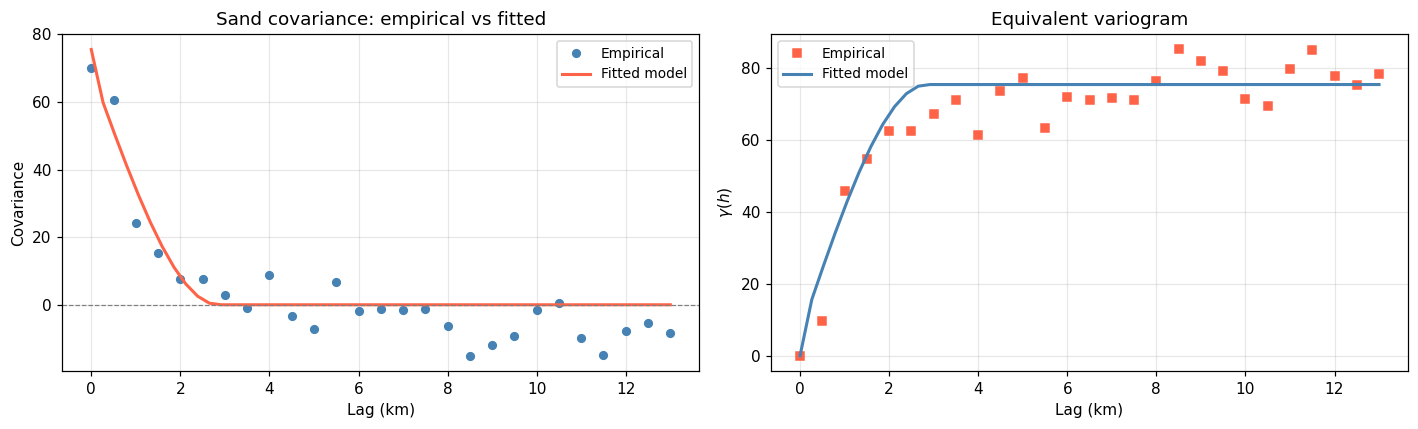

In [5]:
from stamps.models.covmodel import nuggetC, sphericalC

axs = modelplot(cov_h, lag_h,
                covmodel=['nuggetC', 'sphericalC'],
                covparam=fitted_covparam,
                show_variogram=True, lag_scale=1000, lag_unit='km')
axs[0].set_title('Sand covariance: empirical vs fitted')
plt.tight_layout(); plt.show()


## 3. Empirical covariance for silt and clay


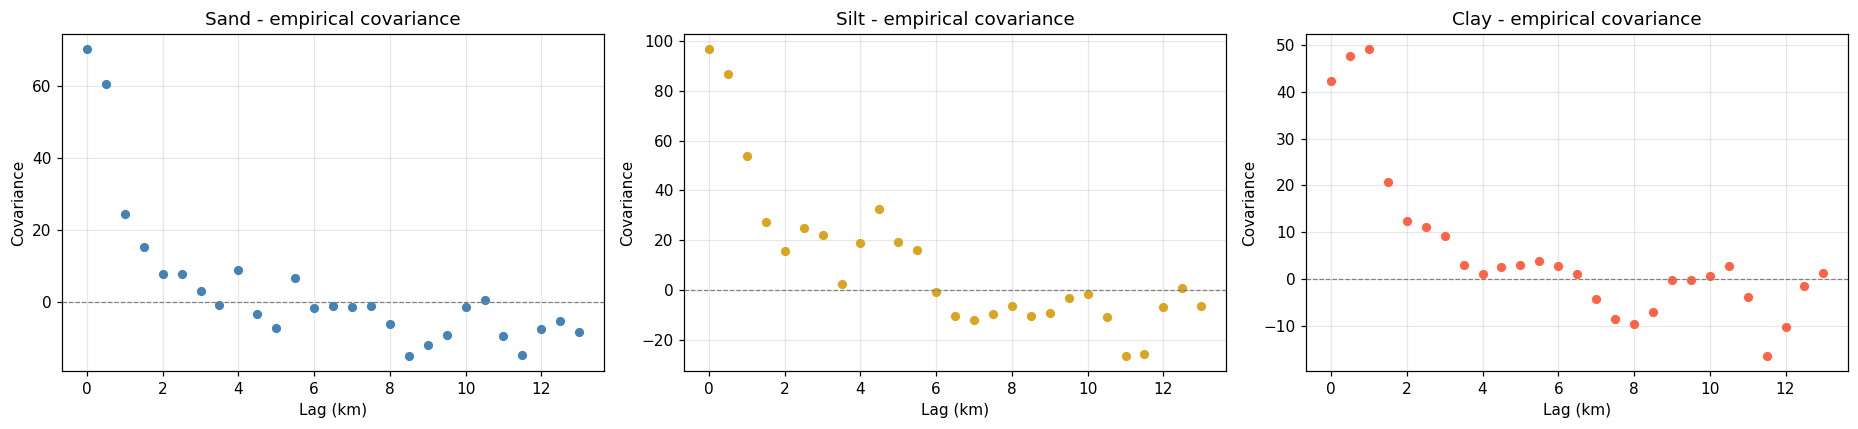

In [6]:
cov_silt, n_silt, lag_s_silt, _ = stcov(ch, None, silt, lagS, lagS_range)
ok = (n_silt > 0) & ~np.isnan(cov_silt)
lag_s_silt, cov_silt, n_silt = lag_s_silt[ok], cov_silt[ok], n_silt[ok]

cov_clay, n_clay, lag_s_clay, _ = stcov(ch, None, clay, lagS, lagS_range)
ok = (n_clay > 0) & ~np.isnan(cov_clay)
lag_s_clay, cov_clay, n_clay = lag_s_clay[ok], cov_clay[ok], n_clay[ok]

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
data_list = [('Sand', lag_h,     cov_h,     'steelblue'),
             ('Silt', lag_s_silt, cov_silt, 'goldenrod'),
             ('Clay', lag_s_clay, cov_clay, 'tomato')]

for ax, (name, lh, ch_cov, col) in zip(axes, data_list):
    ax.plot(lh / 1000, ch_cov, 'o', color=col, ms=5)
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.set_xlabel('Lag (km)'); ax.set_ylabel('Covariance')
    ax.set_title(f'{name} - empirical covariance'); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## 4. Linear Model of Coregionalisation (LMC) with `coregfit`

When working with multiple co-located variables, we need a **jointly valid** cross-covariance model.  The LMC assumes:

$$C_{ij}(h) = \sum_{u=1}^{U} b^{(u)}_{ij}\, g_u(h)$$

where $g_u(h)$ are basic covariance models and $\mathbf{B}^{(u)} = [b^{(u)}_{ij}]$ are positive semi-definite **coregionalisation matrices**.

`coregfit` uses Iterated Alternating Weighted Least Squares (IALS) to estimate the $\mathbf{B}^{(u)}$ matrices jointly.


In [7]:
# Build a 3-variable empirical cross-covariance structure
variables_all = np.column_stack([sand, silt, clay])  # (118, 3)
var_arrays    = [sand, silt, clay]
nv = 3

# Pair labels for cov_data dict
pair_names = ['Sand-Sand', 'Silt-Silt', 'Clay-Clay',
              'Sand-Silt', 'Sand-Clay', 'Silt-Clay']
pair_idx   = [(0,0), (1,1), (2,2), (0,1), (0,2), (1,2)]

def _valid(cv, cn, lags):
    """Filter out empty lag bins from stcov output."""
    ok = (cn > 0) & ~np.isnan(cv)
    return lags[ok], cv[ok], cn[ok]

cov_data = {}
for (i, j), name in zip(pair_idx, pair_names):
    cv_i, cn_i, lh_i, _ = stcov(ch, None, variables_all[:, i], lagS, lagS_range)
    lh_i, cv_i, _ = _valid(cv_i, cn_i, lh_i)
    cov_data[name] = (lh_i, cv_i)

# Shared lag axis (from sand auto-covariance, already computed in Cell 3)
n_lags = len(lag_h)
D_arr  = lag_h

# Auto-covariances on the diagonal of V_tensor
V_tensor = np.zeros((nv, nv, n_lags))
for vi, var in enumerate(var_arrays):
    cv_vi, cn_vi, lh_vi, _ = stcov(ch, None, var, lagS, lagS_range)
    _, cv_vi, _ = _valid(cv_vi, cn_vi, lh_vi)
    n_common = min(n_lags, len(cv_vi))
    V_tensor[vi, vi, :n_common] = cv_vi[:n_common]

# Cross-covariances via the linear combination trick: C_XY = 0.5*(C_(X+Y) - C_X - C_Y)
pairs_xy = [(0, 1), (0, 2), (1, 2)]
for (i, j) in pairs_xy:
    zi, zj = var_arrays[i], var_arrays[j]

    cv_sum, cn_sum, lh_sum, _ = stcov(ch, None, zi + zj, lagS, lagS_range)
    _, cv_sum, _ = _valid(cv_sum, cn_sum, lh_sum)

    cv_i, cn_i, lh_i, _ = stcov(ch, None, zi, lagS, lagS_range)
    _, cv_i, _ = _valid(cv_i, cn_i, lh_i)

    cv_j, cn_j, lh_j, _ = stcov(ch, None, zj, lagS, lagS_range)
    _, cv_j, _ = _valid(cv_j, cn_j, lh_j)

    n_c = min(n_lags, len(cv_sum), len(cv_i), len(cv_j))
    V_tensor[i, j, :n_c] = 0.5 * (cv_sum[:n_c] - cv_i[:n_c] - cv_j[:n_c])
    V_tensor[j, i, :n_c] = V_tensor[i, j, :n_c]  # symmetry

print('Cross-covariance tensor shape:', V_tensor.shape)
print('C(0) matrix (variance-covariance at lag 0):')
print(np.round(V_tensor[:, :, 0], 2))


Cross-covariance tensor shape: (3, 3, 27)
C(0) matrix (variance-covariance at lag 0):
[[ 70.13 -62.2   -7.88]
 [-62.2   96.61 -34.42]
 [ -7.88 -34.42  42.26]]


In [8]:
# Fit LMC: nugget + spherical structure
lmc_model  = ['nuggetC', 'sphericalC']
lmc_param0 = [(10.0,), (50.0, [5_000.0])]

# coregfit(d, V, o, model, param0)
# d: (n_lags,) lag values
# V: (nv, nv, n_lags) cross-covariance tensor
# o: (n_lags,) weights (use pair counts, approximate here)
o_weights = n_h.copy()   # use sand pair counts as weights

lmc_result = coregfit(D_arr, V_tensor, o_weights, lmc_model, lmc_param0)

print('LMC fitting result:')
for s in lmc_result:
    print(f'  Structure: {s["model"]}')
    print(f'    Sill matrix (B):\n{np.round(s["sill_matrix"], 2)}')
    if s.get('range_param') is not None:
        rp = s['range_param']
        rp_val = float(rp[0]) if hasattr(rp, '__len__') else float(rp)
        print(f'    Range: {rp_val:.1f} m')


LMC fitting result:
  Structure: nuggetC
    Sill matrix (B):
[[ 24.42 -21.21  -3.08]
 [-21.21  18.5    2.68]
 [ -3.08   2.68   0.43]]
  Structure: sphericalC
    Sill matrix (B):
[[ 46.52 -39.81  -6.66]
 [-39.81  79.91 -39.93]
 [ -6.66 -39.93  46.52]]
    Range: 5000.0 m


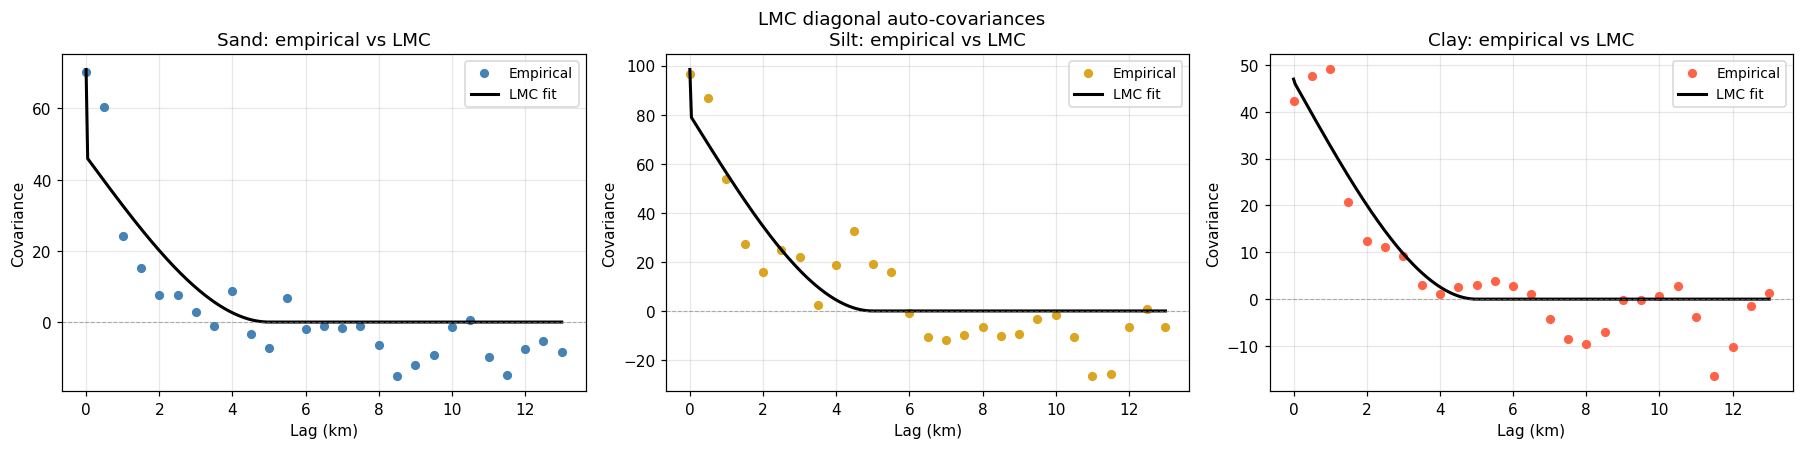

In [9]:
from stamps.graph.modelplot import lmcplot

axes = lmcplot(
    lmc_result, V_tensor, D_arr,
    varnames=['Sand', 'Silt', 'Clay'],
    colors=['steelblue', 'goldenrod', 'tomato'],
    lag_scale=1_000, lag_unit='km',
)
axes[0].get_figure().suptitle('LMC diagonal auto-covariances', fontsize=12, y=1.01)
plt.show()


## 5. Normal Score Transformation (NST)

Many geostatistical methods (especially BME) assume **Gaussian marginals**.  The Normal Score Transformation maps the original data $z$ to a Gaussian variable $y$ via the empirical CDF:

$$y_i = \Phi^{-1}\!\left[\hat{F}(z_i)\right]$$

After transformation, we can fit a covariance model in Gaussian space and back-transform the results.

`stamps.bme.bme_transform.other2gauss` implements this using a reference CDF (either empirical or user-supplied).


In [10]:
# Normal Score Transform for sand
# other2gauss(z, yfile, cdfyfile)
# yfile    : reference y values (Gaussian quantiles)
# cdfyfile : corresponding CDF values

# Build empirical CDF for sand
z_sorted = np.sort(sand)
n        = len(z_sorted)
p_vals   = (np.arange(1, n + 1) - 0.5) / n    # Hazen plotting position

from scipy.stats import norm
y_gauss = norm.ppf(p_vals)                      # Gaussian quantiles

# Apply NST via other2gauss
sand_nst = other2gauss(sand, z_sorted, p_vals)

print(f'Original sand: mean={sand.mean():.2f}, std={sand.std():.2f}')
print(f'NST sand:      mean={sand_nst.mean():.4f}, std={sand_nst.std():.4f}')


Original sand: mean=15.18, std=9.51
NST sand:      mean=0.0061, std=0.9903


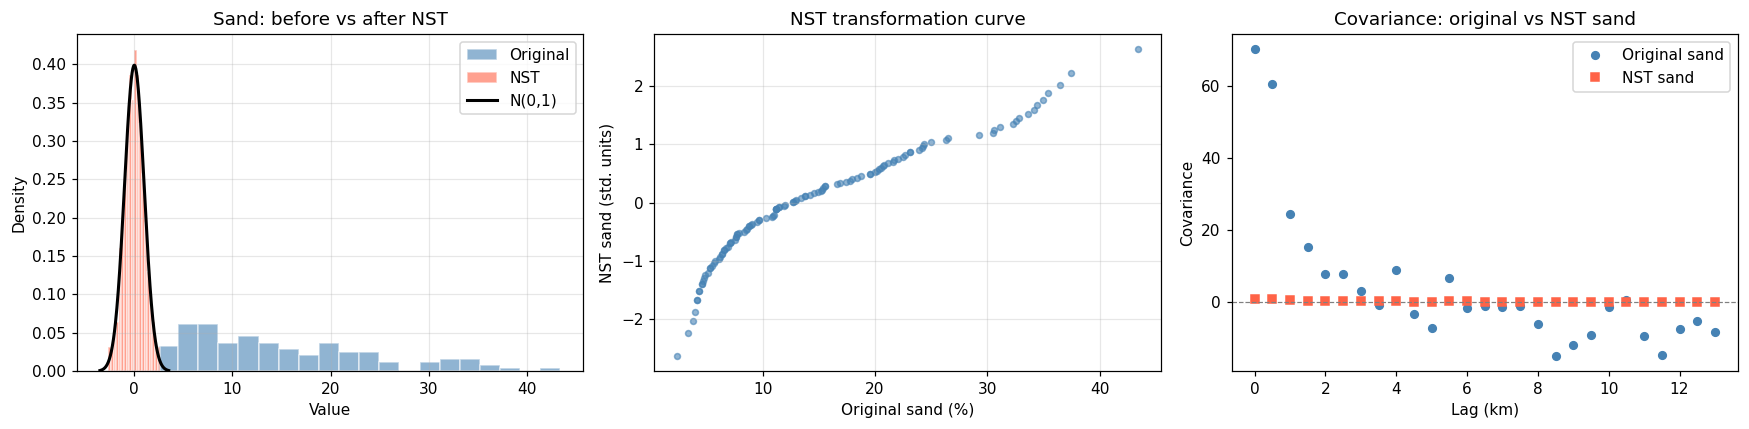

In [11]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram comparison using enhanced histplot
histplot(sand, bins=20, ax=axes[0], density=True, color='steelblue',
         alpha=0.6, label='Original', xlabel='Value', show=False)
histplot(sand_nst, bins=20, ax=axes[0], density=True, color='tomato',
         alpha=0.6, label='NST', xlabel='Value', show=False)
h_ax = np.linspace(-3.5, 3.5, 200)
axes[0].plot(h_ax, norm.pdf(h_ax), 'k-', lw=2, label='N(0,1)')
axes[0].set_title('Sand: before vs after NST'); axes[0].legend()

# Scatter: original vs transformed
ax = axes[1]
ax.scatter(sand, sand_nst, s=15, alpha=0.6, color='steelblue')
ax.set_xlabel('Original sand (%)'); ax.set_ylabel('NST sand (std. units)')
ax.set_title('NST transformation curve'); ax.grid(True, alpha=0.3)

# Empirical covariance in transformed space
cov_nst, n_nst, lh_nst, _ = stcov(ch, None, sand_nst, lagS, lagS_range)
ok_nst = (n_nst > 0) & ~np.isnan(cov_nst)
lh_nst, cov_nst, n_nst = lh_nst[ok_nst], cov_nst[ok_nst], n_nst[ok_nst]
ax = axes[2]
ax.plot(lag_h / 1000,  cov_h,   'o', color='steelblue', ms=5, label='Original sand')
ax.plot(lh_nst / 1000, cov_nst, 's', color='tomato',    ms=5, label='NST sand')
ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.set_xlabel('Lag (km)'); ax.set_ylabel('Covariance')
ax.set_title('Covariance: original vs NST sand'); ax.legend()

plt.tight_layout(); plt.show()


starpy Warning: roundoff limited found. Set relative value to 10**-8
NST model parameters:
  nuggetC: [0.015]
  sphericalC: [0.7584, 2937.3807]


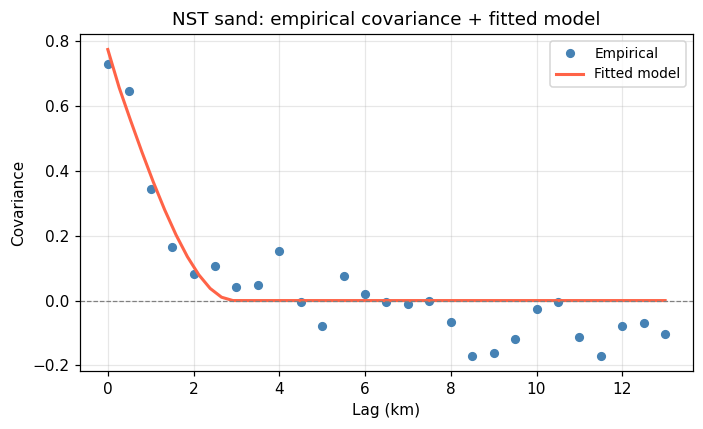

In [12]:
# Fit covariance model to NST-transformed data
lag_cov_v_nst = cov_nst.reshape(-1, 1)
lag_cov_n_nst = n_nst.reshape(-1, 1)
lag_cov_s_nst = lh_nst.reshape(-1, 1)

fitted_nst, _opt17 = covmodelfit(lag_cov_s_nst, np.array([[0.0]]),
                                   lag_cov_v_nst, lag_cov_n_nst,
                                   ['nuggetC', 'sphericalC'],
                                   [(0.05,), (0.95, 5_000.0)])
print('NST model parameters:')
for m, p in zip(['nuggetC', 'sphericalC'], fitted_nst):
    vals = [round(float(np.asarray(v).flat[0]), 4) for v in p]
    print(f'  {m}: {vals}')

h_plot = np.linspace(0, lh_nst.max(), 300)
C_nst_fitted = (nuggetC(h_plot, *fitted_nst[0])
               + sphericalC(h_plot, *fitted_nst[1]))

axs = modelplot(cov_nst, lh_nst,
                covmodel=['nuggetC', 'sphericalC'],
                covparam=fitted_nst,
                lag_scale=1000, lag_unit='km')
axs[0].set_title('NST sand: empirical covariance + fitted model')
plt.tight_layout(); plt.show()


## 6. Save covariance parameters for downstream notebooks


In [13]:
import pickle

cov_params = {
    # Univariate (sand) in original space
    'sand_covmodel':  ['nuggetC', 'sphericalC'],
    'sand_covparam':  fitted_covparam,
    # Univariate (sand) in NST space
    'sand_nst_covmodel': ['nuggetC', 'sphericalC'],
    'sand_nst_covparam': fitted_nst,
    # NST CDF (for back-transformation)
    'sand_z_sorted': z_sorted,
    'sand_p_vals':   p_vals,
    # LMC result
    'lmc_model':  lmc_model,
    'lmc_result': lmc_result,
    # Empirical lag data
    'lag_h': lag_h, 'cov_h': cov_h, 'n_h': n_h,
}

save_path = os.path.join(DATA_DIR, 'tutorial03_cov.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(cov_params, f)
print('Saved:', save_path)


Saved: /Users/hdragon689/Documents/MyDoc_iCloud/packages/stamps/stamps_v3/tutorials/data/tutorial03_cov.pkl


## 7. Summary

| Step | stamps_v3 function |
|---|---|
| Empirical covariance | `stcov(grid_s, grid_t, grid_v, lagS, lagS_range)` |
| WLS model fitting | `covmodelfit(lag_s, lag_t, lag_v, lag_n, model, param0)` |
| LMC cross-covariance fitting | `coregfit(d, V, o, model, param0)` |
| Normal Score Transformation | `other2gauss(z, z_sorted, p_vals)` |

**Next:** Tutorial 04 — Kriging, Cokriging & Kriging with Transformation.
